# D206 Performance Assessment

## Part I: Research Question

### A.  Describe one question or decision that could be addressed using the data set you chose. The summarized question or decision must be relevant to a realistic organizational need or situation.

A question that could be addressed using the medical data set is whether men who are married have lower rates of high blood pressure than men who are not married. This question is relevant as high blood pressure is a chronic condition that often requires medical attention. If the hypothesis is correct and men who are married have lower rates of high blood pressure than unmarried men, separate treatment plans could be created to help tailor medical care in a way that suits each group (married men versus unmarried men). For example, unmarried men could be advised to test their blood pressure more frequently.

### B.  Describe all variables in the data set (regardless of the research question) and indicate the data type for each variable. Use examples from the data set to support your claims.

Please see the attached table titled "D206 1B Table" that has been uploaded as part of this performance assessment for the answer to this question.

## Part II: Data-Cleaning Plan

### C.  Explain the plan for cleaning the data by doing the following:

#### 1.  Propose a plan that includes the relevant techniques and specific steps needed to assess the quality of the data in the data set.

Duplicate detection will be done using the duplicated() function and value_counts() function on the dataframe to see if there are any duplicates.

Missing value detection will be done using the isnull() function and sum() function to return the sums of null values in each column. Missingness will be visualized using a missingno matrix.

Three variables (Zip, Overweight, Anxiety) have incorrect data types that were identified using the dtypes command on the medical data set and will need to be corrected.

Outliers will be detected for all quantitative variables using a combination of histograms, z-scores, and box plots. The "Children," "Age," "Income," and "Initial_days" variables have missing values and will need to be imputed before assessing outliers for these variables.

Correct presentation of categorical variables will be assessed by examining the unique values of each column using the unique() function. Categorical variables that could be ordinally encoded will be identified and will later be ordinally encoded.

#### 2.  Justify your approach for assessing the quality of the data, including the following: characteristics of the data being assessed, the approach used to assess the quality of the data

Duplicate detection: 

In Nkmk (2021), it is stated that the “duplicated() method returns Boolean pandas.Series with duplicate rows as True.” Using this functions allows for the identification of which columns have duplicated rows. 
The value_counts() function was used because, as stated in Webinar 2 (Middleton, 2022a), this method is used to “determine the sum of duplicates records within your dataset.” Appending the two functions together as I have done shows the total duplicates in the dataset.

Missing value detection:

The isnull() and sum() functions were used to identify the sums of null values in each column. In Webinar 2 (Middleton, 2022a), this method is noted as a way to “detect whether null values exist within the dataset.” Additionally, a missing value matrix was used to visualize the type of missingness in each column with missing data. This was done using the “missingno matrix” method described in Webinar 2 (Middleton, 2022a).

Assessing Correct data types: 

“Zip,” “Overweight,” and “Anxiety” all had numeric datatypes despite not being numeric objects. In order to be able to run the correct analyses if needed, these three columns were converted to objects using the .astype() function, described in Webinar 2 (Middleton, 2022a).

Outlier detection:

Outlier detection was done using three methods: z-scores, boxplots, and histograms. 
Regarding z-scores, in Section 3.8 of the textbook (Larose & Larose, 2019), it is noted that “One may use the z-values to identify outliers, which are records with extreme values along a particular dimension or dimensions.” In order to determine what constitutes an outlier, the book states “A rough rule of thumb is that a data value is an outlier if its z-value is either greater than 3, or less than -3.

Boxplots were used to visualize the outliers in the specified columns in the dataset. By visualizing outliers, it is easy to quickly identify which values are outliers. Webinar 2 (Middleton, 2022a) notes that “Box plots are useful as they provide a visual summary of the data to quickly identify mean values, the dispersion of the data set, signs of skewness, and outliers.”

Histograms were also used to visualize outliers at a glance. This helped provide an additional visualization to help potentially identify any visual outliers that did not stand out as much in the boxplot. According to Webinar 2 (Middleton, 2022a), “A histogram is the most used graph to show frequency distributions. Histograms emphasize the existence of outliers.” 

Categorical variable re-expression:

Categorical variables were assessed to determine whether they could be re-expressed via ordinal encoding. In Chapter 3.6 of the textbook (Larose & Larose, 2019), it is said that “If we left the field as it is, then our data science algorithms would not know that university degree represents more education than basic.4yr. To provide this information to our algorithms, we transform the data values into numeric values, where it is clear that one value is larger than another.”

In order to re-express the variables that required re-expressing, a data dictionary was used to convert the values of the columns to numeric. This will make it easier for statistical analysis to be performed on these categorical variables.

#### 3.  Justify your selected programming language and any libraries and packages that will support the data-cleaning process.

The programming language I used to clean my data was Python. I have some programming experience, and according to the “R or Python” website by WGU, Python is seen as easier to learn than R for people with software engineering experience.

I am someone who prefers to learn as I go, so the relative ease of Python syntax combined with the widely available resources for understanding new packages was ideal for me as I worked on this assignment. 

Python is handy for doing data analysis, in part because of the wide variety of packages that are available to use. For this assignment, the packages I used were “pandas,” “numpy,” “missingno,” “scipy.stats,” “matplotlib.pyplot,” “seaborn,” and “PCA” from the “sklearn.decomposition” library.

In (R Or Python, 2022) by WGU, it is noted that pandas is used “to easily manipulate data.” Additionally, numpy and scipy are useful for scientific computing. Seaborn and matplotlib are useful for creating graphs and graphics, as has been done. Missingno was used to create the missing values matrix, and sklearn was used to perform the Principle Component Analysis portion of the assignment.

#### 4.  Provide the annotated code you will use to assess the quality of the data in an executable script file.

In [1]:
#Import libraries
import pandas as pd
import numpy as np
import missingno as msno
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn
from sklearn.decomposition import PCA

#Read in file
filename = "medical_raw_data.csv"
medical_data = pd.read_csv(filename)

#Detect Duplicates
print(medical_data.duplicated().value_counts())

False    10000
dtype: int64


<AxesSubplot:>

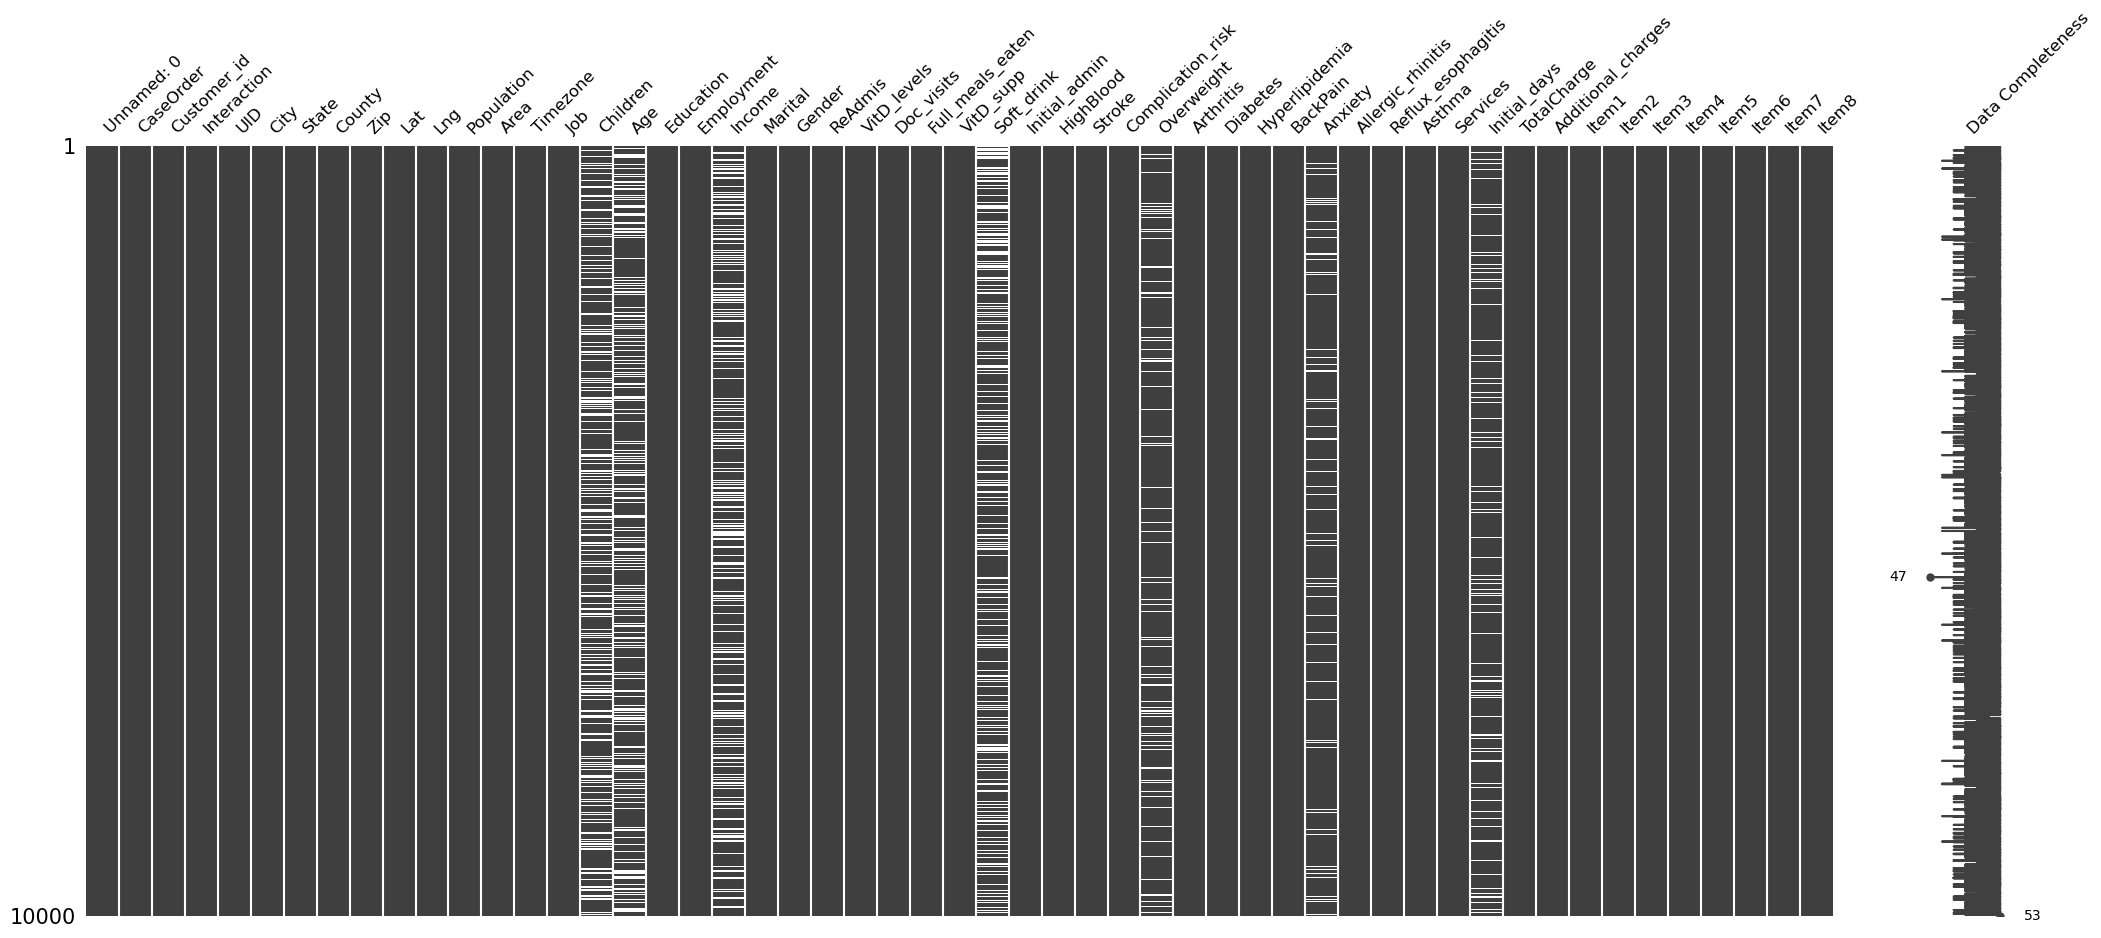

In [2]:
#Visualize missingness
msno.matrix(medical_data, fontsize = 12, labels = True)

In [3]:
#Identify that Zip, Overweight, and Anxiety are incorrect object types
print(medical_data.dtypes)

Unnamed: 0              int64
CaseOrder               int64
Customer_id            object
Interaction            object
UID                    object
City                   object
State                  object
County                 object
Zip                     int64
Lat                   float64
Lng                   float64
Population              int64
Area                   object
Timezone               object
Job                    object
Children              float64
Age                   float64
Education              object
Employment             object
Income                float64
Marital                object
Gender                 object
ReAdmis                object
VitD_levels           float64
Doc_visits              int64
Full_meals_eaten        int64
VitD_supp               int64
Soft_drink             object
Initial_admin          object
HighBlood              object
Stroke                 object
Complication_risk      object
Overweight            float64
Arthritis 

In [4]:
#Detect missing values
print(medical_data.isnull().sum())

Unnamed: 0               0
CaseOrder                0
Customer_id              0
Interaction              0
UID                      0
City                     0
State                    0
County                   0
Zip                      0
Lat                      0
Lng                      0
Population               0
Area                     0
Timezone                 0
Job                      0
Children              2588
Age                   2414
Education                0
Employment               0
Income                2464
Marital                  0
Gender                   0
ReAdmis                  0
VitD_levels              0
Doc_visits               0
Full_meals_eaten         0
VitD_supp                0
Soft_drink            2467
Initial_admin            0
HighBlood                0
Stroke                   0
Complication_risk        0
Overweight             982
Arthritis                0
Diabetes                 0
Hyperlipidemia           0
BackPain                 0
A

In [6]:
#Change data type for Zip, Overweight, Anxiety to object. Verify if it worked.
medical_data['Zip'] = medical_data['Zip'].astype('object')
medical_data['Overweight'] = medical_data['Overweight'].astype('object')
medical_data['Anxiety'] = medical_data['Anxiety'].astype('object')
print(medical_data.dtypes)

Unnamed: 0              int64
CaseOrder               int64
Customer_id            object
Interaction            object
UID                    object
City                   object
State                  object
County                 object
Zip                    object
Lat                   float64
Lng                   float64
Population              int64
Area                   object
Timezone               object
Job                    object
Children              float64
Age                   float64
Education              object
Employment             object
Income                float64
Marital                object
Gender                 object
ReAdmis                object
VitD_levels           float64
Doc_visits              int64
Full_meals_eaten        int64
VitD_supp               int64
Soft_drink             object
Initial_admin          object
HighBlood              object
Stroke                 object
Complication_risk      object
Overweight             object
Arthritis 

(array([7.328e+03, 1.203e+03, 7.630e+02, 3.950e+02, 1.860e+02, 7.500e+01,
        2.600e+01, 1.800e+01, 4.000e+00, 2.000e+00]),
 array([-0.67223706,  0.15624281,  0.98472269,  1.81320256,  2.64168243,
         3.4701623 ,  4.29864217,  5.12712205,  5.95560192,  6.78408179,
         7.61256166]),
 <BarContainer object of 10 artists>)

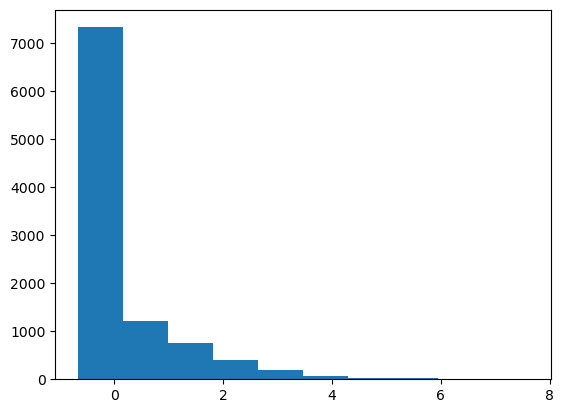

In [7]:
#Outlier detection for quantitative variables
#Population
#Outlier assessment via histogram
medical_data['Z_Score_Population']=stats.zscore(medical_data['Population'])
medical_data[['Population', 'Z_Score_Population']].head
plt.hist(medical_data['Z_Score_Population'])

count       218.000000
mean      67419.325688
std       13341.793468
min       54453.000000
25%       57437.250000
50%       63165.000000
75%       71236.750000
max      122814.000000
Name: Population, dtype: float64

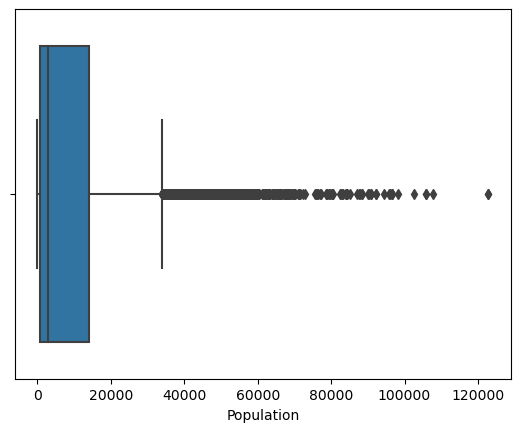

In [8]:
#Population
#Outlier assessment via box plot
population_boxplot=seaborn.boxplot(x='Population', data=medical_data)
population_outliers = medical_data.query('Z_Score_Population > 3 | Z_Score_Population < -3')
population_outliers['Population'].describe()

In [9]:
#Children
#Imputation before outlier assessment
medical_data['Children'].fillna(medical_data['Children'].median(), inplace = True)

(array([1880., 5540.,    0., 1113.,  739.,  126.,  299.,    0.,  157.,
         146.]),
 array([-0.94633266, -0.42464983,  0.09703301,  0.61871584,  1.14039868,
         1.66208151,  2.18376435,  2.70544718,  3.22713002,  3.74881285,
         4.27049569]),
 <BarContainer object of 10 artists>)

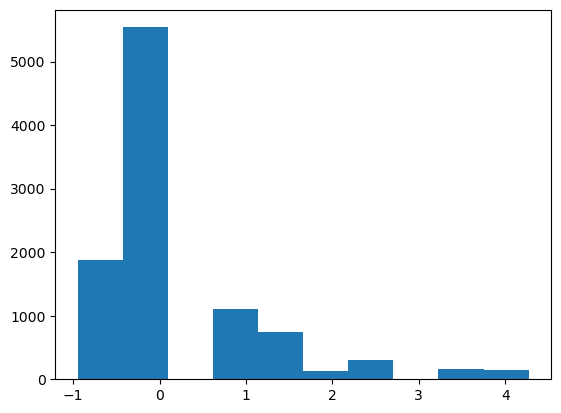

In [10]:
#Children
#Outlier assessment via histogram
medical_data['Z_Score_Children']=stats.zscore(medical_data['Children'])
medical_data[['Children', 'Z_Score_Children']].head
plt.hist(medical_data['Z_Score_Children'])

count    303.000000
mean       8.689769
std        0.794931
min        8.000000
25%        8.000000
50%        8.000000
75%        9.000000
max       10.000000
Name: Children, dtype: float64

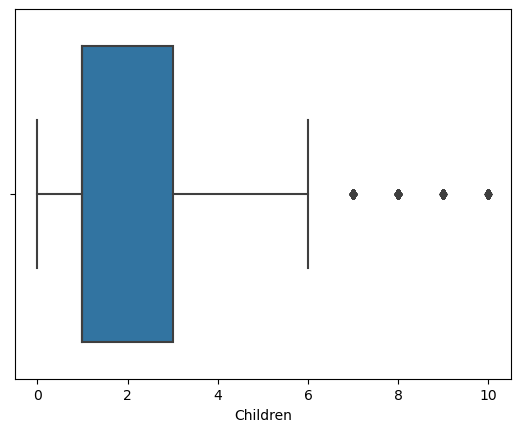

In [11]:
#Children
#Outlier assessment via box plot
children_boxplot=seaborn.boxplot(x='Children', data=medical_data)
children_outliers = medical_data.query('Z_Score_Children > 3 | Z_Score_Children < -3')
children_outliers['Children'].describe()

In [12]:
#Age
#Imputation before outlier assessment
medical_data['Age'].fillna(medical_data['Age'].mean(), inplace = True)

(array([ 823.,  761.,  746.,  753., 3160.,  739.,  730.,  765.,  710.,
         813.]),
 array([-1.96169093, -1.56708153, -1.17247213, -0.77786273, -0.38325333,
         0.01135607,  0.40596547,  0.80057486,  1.19518426,  1.58979366,
         1.98440306]),
 <BarContainer object of 10 artists>)

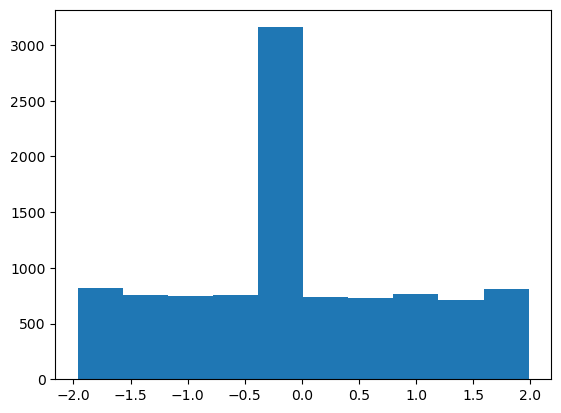

In [13]:
#Age
#Outlier assessment via histogram
medical_data['Z_Score_Age']=stats.zscore(medical_data['Age'])
medical_data[['Age', 'Z_Score_Age']].head
plt.hist(medical_data['Z_Score_Age'])

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Age, dtype: float64

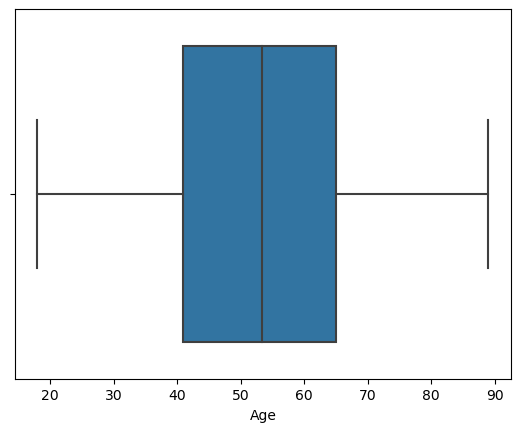

In [14]:
#Age
#Outlier assessment via box plot
age_boxplot=seaborn.boxplot(x='Age', data=medical_data)
age_outliers = medical_data.query('Z_Score_Age > 3 | Z_Score_Age < -3')
age_outliers['Age'].describe()

In [15]:
#Income
#Imputation before outlier assessment
medical_data['Income'].fillna(medical_data['Income'].median(), inplace = True)

(array([2068., 4990., 1532.,  790.,  340.,  156.,   67.,   34.,   12.,
          11.]),
 array([-1.54616546, -0.71915955,  0.10784637,  0.93485228,  1.76185819,
         2.5888641 ,  3.41587002,  4.24287593,  5.06988184,  5.89688776,
         6.72389367]),
 <BarContainer object of 10 artists>)

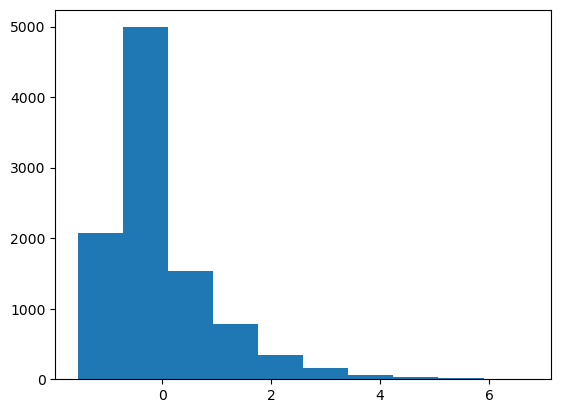

In [16]:
#Income
#Outlier assessment via histogram
medical_data['Z_Score_Income']=stats.zscore(medical_data['Income'])
medical_data[['Income', 'Z_Score_Income']].head
plt.hist(medical_data['Z_Score_Income'])

count       180.000000
mean     138626.749056
std       21845.608414
min      114215.990000
25%      121653.280000
50%      131921.650000
75%      148366.355000
max      207249.130000
Name: Income, dtype: float64

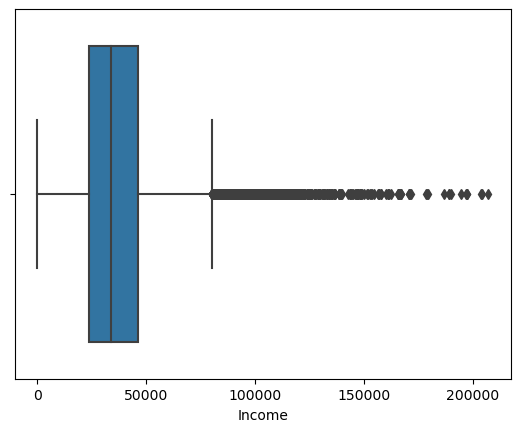

In [17]:
#Income
#Outlier assessment via box plot
income_boxplot=seaborn.boxplot(x='Income', data=medical_data)
income_outliers = medical_data.query('Z_Score_Income > 3 | Z_Score_Income < -3')
income_outliers['Income'].describe()

(array([ 313., 4930., 4063.,  194.,    0.,    0.,    0.,   49.,  329.,
         122.]),
 array([-1.47162731, -0.8245874 , -0.17754748,  0.46949244,  1.11653235,
         1.76357227,  2.41061218,  3.0576521 ,  3.70469201,  4.35173193,
         4.99877184]),
 <BarContainer object of 10 artists>)

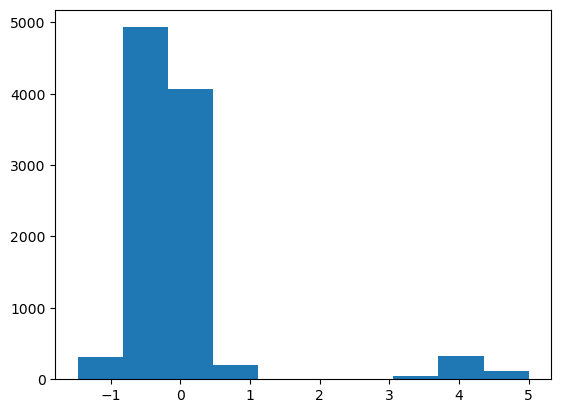

In [18]:
#VitD_levels
#Outlier assessment via histogram
medical_data['Z_Score_VitD_levels']=stats.zscore(medical_data['VitD_levels'])
medical_data[['VitD_levels', 'Z_Score_VitD_levels']].head
plt.hist(medical_data['Z_Score_VitD_levels'])

count    500.000000
mean      47.028970
std        2.211876
min       40.841671
25%       45.418318
50%       47.015313
75%       48.597056
max       53.019124
Name: VitD_levels, dtype: float64

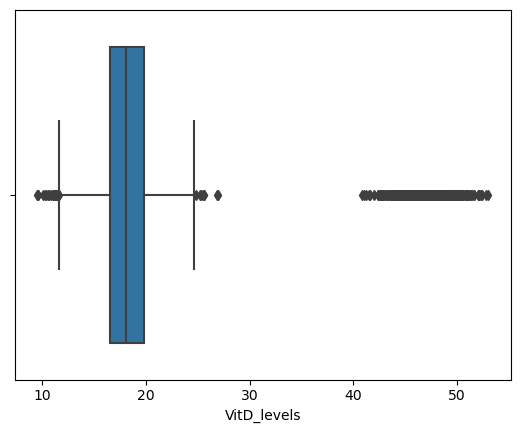

In [19]:
#VitD_levels
#Outlier assessment via box plot
vitD_levels_boxplot=seaborn.boxplot(x='VitD_levels', data=medical_data)
vitD_levels_outliers = medical_data.query('Z_Score_VitD_levels > 3 | Z_Score_VitD_levels < -3')
vitD_levels_outliers['VitD_levels'].describe()

(array([6.000e+00, 5.800e+01, 5.950e+02, 2.385e+03, 0.000e+00, 3.823e+03,
        2.436e+03, 6.340e+02, 6.100e+01, 2.000e+00]),
 array([-3.83692119, -3.07187036, -2.30681952, -1.54176869, -0.77671786,
        -0.01166703,  0.75338381,  1.51843464,  2.28348547,  3.04853631,
         3.81358714]),
 <BarContainer object of 10 artists>)

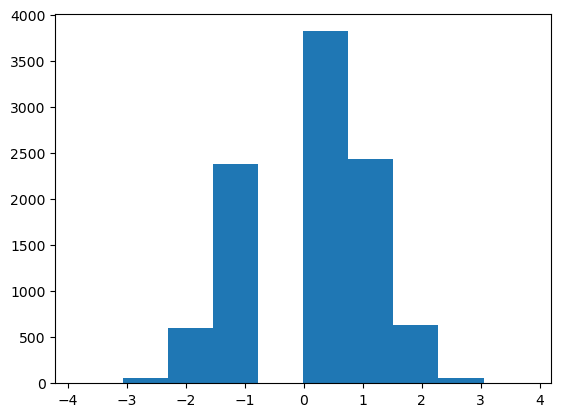

In [20]:
#Doc_visits
#Outlier assessment via histogram
medical_data['Z_Score_Doc_visits']=stats.zscore(medical_data['Doc_visits'])
medical_data[['Doc_visits', 'Z_Score_Doc_visits']].head
plt.hist(medical_data['Z_Score_Doc_visits'])

count    8.00000
mean     3.00000
std      3.70328
min      1.00000
25%      1.00000
50%      1.00000
75%      3.00000
max      9.00000
Name: Doc_visits, dtype: float64

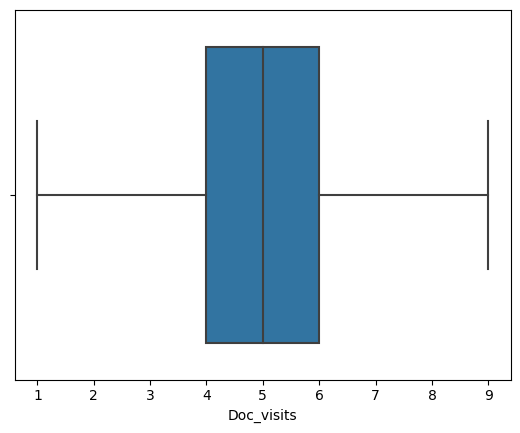

In [21]:
#Doc_visits
#Outlier assessment via box plot
doc_visits_boxplot=seaborn.boxplot(x='Doc_visits', data=medical_data)
doc_visits_outliers = medical_data.query('Z_Score_Doc_visits > 3 | Z_Score_Doc_visits < -3')
doc_visits_outliers['Doc_visits'].describe()

(array([3.715e+03, 3.615e+03, 1.856e+03, 0.000e+00, 6.120e+02, 1.690e+02,
        0.000e+00, 2.500e+01, 6.000e+00, 2.000e+00]),
 array([-0.99338686, -0.29898822,  0.39541043,  1.08980907,  1.78420771,
         2.47860636,  3.173005  ,  3.86740364,  4.56180229,  5.25620093,
         5.95059957]),
 <BarContainer object of 10 artists>)

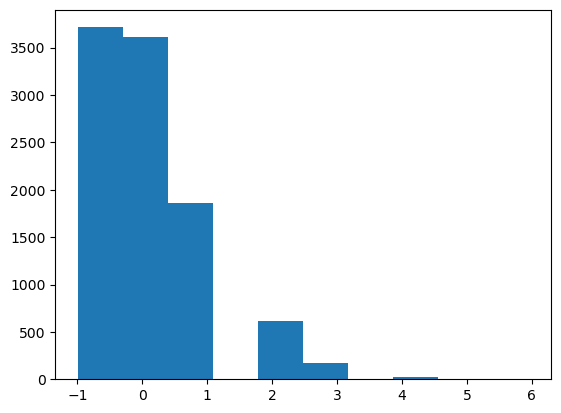

In [22]:
#Full_meals_eaten
#Outlier assessment via histogram
medical_data['Z_Score_Full_meals_eaten']=stats.zscore(medical_data['Full_meals_eaten'])
medical_data[['Full_meals_eaten', 'Z_Score_Full_meals_eaten']].head
plt.hist(medical_data['Z_Score_Full_meals_eaten'])

count    33.000000
mean      5.303030
std       0.585494
min       5.000000
25%       5.000000
50%       5.000000
75%       5.000000
max       7.000000
Name: Full_meals_eaten, dtype: float64

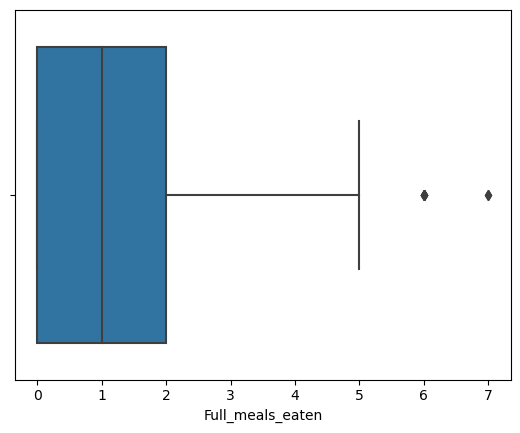

In [23]:
#Full_meals_eaten
#Outlier assessment via box plot
full_meals_eaten_boxplot=seaborn.boxplot(x='Full_meals_eaten', data=medical_data)
full_meals_eaten_outliers = medical_data.query('Z_Score_Full_meals_eaten > 3 | Z_Score_Full_meals_eaten < -3')
full_meals_eaten_outliers['Full_meals_eaten'].describe()

(array([6.702e+03, 2.684e+03, 0.000e+00, 5.440e+02, 0.000e+00, 0.000e+00,
        6.400e+01, 0.000e+00, 5.000e+00, 1.000e+00]),
 array([-0.63471264,  0.160866  ,  0.95644465,  1.75202329,  2.54760193,
         3.34318058,  4.13875922,  4.93433787,  5.72991651,  6.52549516,
         7.3210738 ]),
 <BarContainer object of 10 artists>)

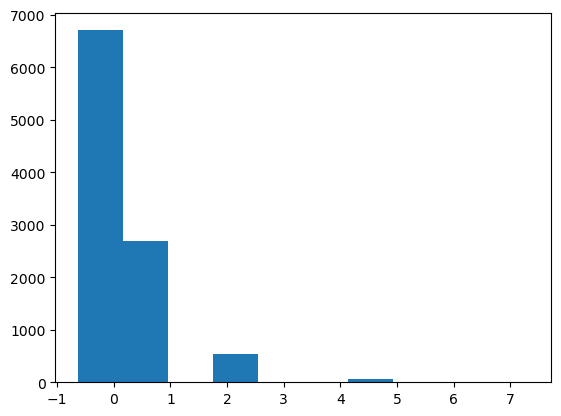

In [24]:
#VitD_supp
#Outlier assessment via histogram
medical_data['Z_Score_VitD_supp']=stats.zscore(medical_data['VitD_supp'])
medical_data[['VitD_supp', 'Z_Score_VitD_supp']].head
plt.hist(medical_data['Z_Score_VitD_supp'])

count    70.000000
mean      3.100000
std       0.346828
min       3.000000
25%       3.000000
50%       3.000000
75%       3.000000
max       5.000000
Name: VitD_supp, dtype: float64

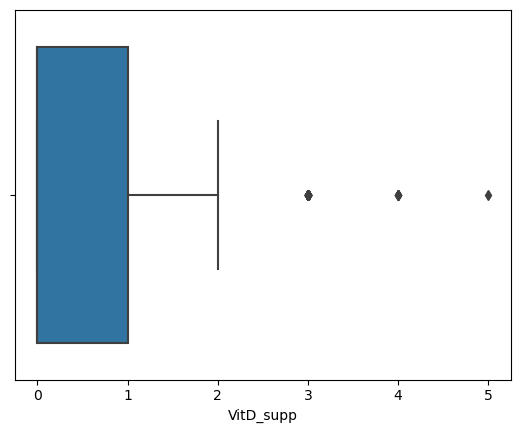

In [25]:
#VitD_supp
#Outlier assessment via box plot
vitd_supp_boxplot=seaborn.boxplot(x='VitD_supp', data=medical_data)
vitd_supp_outliers = medical_data.query('Z_Score_VitD_supp > 3 | Z_Score_VitD_supp < -3')
vitd_supp_outliers['VitD_supp'].describe()

In [26]:
#Initial_days
#Imputation before outlier assessment
medical_data['Initial_days'].fillna(medical_data['Children'].median(), inplace = True)

(array([3344., 1429.,  599.,  134.,   32.,  235.,  502.,  916., 1314.,
        1495.]),
 array([-1.11164329, -0.84775791, -0.58387253, -0.31998715, -0.05610178,
         0.2077836 ,  0.47166898,  0.73555436,  0.99943974,  1.26332512,
         1.5272105 ]),
 <BarContainer object of 10 artists>)

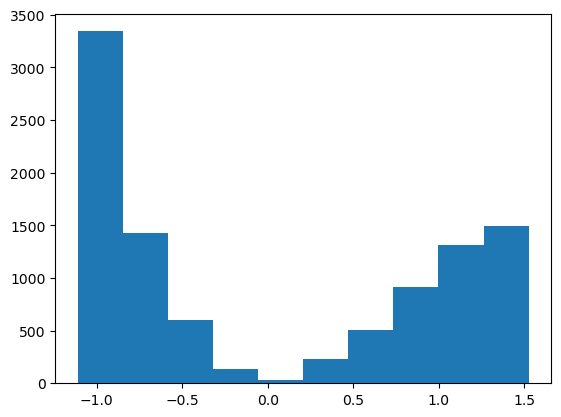

In [27]:
#Initial_days
#Outlier assessment via histogram
medical_data['Z_Score_Initial_days']=stats.zscore(medical_data['Initial_days'])
medical_data[['Initial_days', 'Z_Score_Initial_days']].head
plt.hist(medical_data['Z_Score_Initial_days'])

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Initial_days, dtype: float64

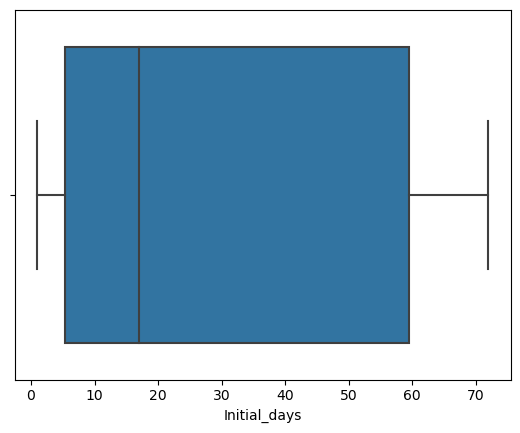

In [28]:
#Initial_days
#Outlier assessment via box plot
initial_days_boxplot=seaborn.boxplot(x='Initial_days', data=medical_data)
initial_days_outliers = medical_data.query('Z_Score_Initial_days > 3 | Z_Score_Initial_days < -3')
initial_days_outliers['Initial_days'].describe()

(array([2587., 2204., 2136., 2553.,   20.,    5.,  187.,   63.,  167.,
          78.]),
 array([-1.37229861, -0.77220572, -0.17211284,  0.42798004,  1.02807292,
         1.6281658 ,  2.22825869,  2.82835157,  3.42844445,  4.02853733,
         4.62863021]),
 <BarContainer object of 10 artists>)

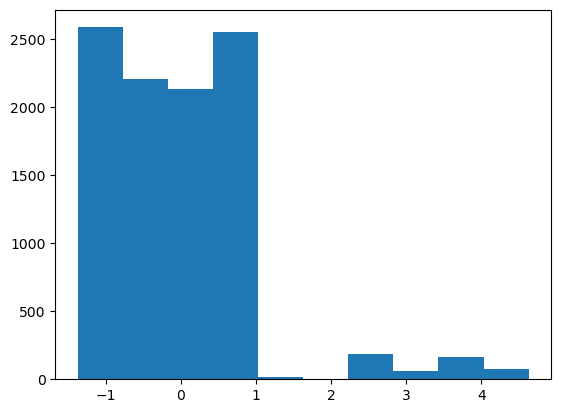

In [29]:
#TotalCharge
#Outlier assessment via histogram
medical_data['Z_Score_TotalCharge']=stats.zscore(medical_data['TotalCharge'])
medical_data[['TotalCharge', 'Z_Score_TotalCharge']].head
plt.hist(medical_data['Z_Score_TotalCharge'])

count      276.000000
mean     18862.987055
std       1052.013576
min      16053.462880
25%      18315.537830
50%      18983.908835
75%      19607.727452
max      21524.224210
Name: TotalCharge, dtype: float64

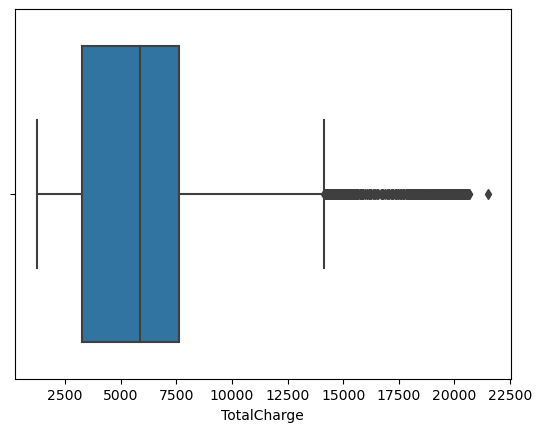

In [30]:
#TotalCharge
#Outlier assessment via box plot
totalCharge_boxplot=seaborn.boxplot(x='TotalCharge', data=medical_data)
totalCharge_outliers = medical_data.query('Z_Score_TotalCharge > 3 | Z_Score_TotalCharge < -3')
totalCharge_outliers['TotalCharge'].describe()

(array([1120., 1818., 1891., 1856., 1032.,  497.,  494.,  507.,  487.,
         298.]),
 array([-1.49929906, -1.0798674 , -0.66043573, -0.24100407,  0.1784276 ,
         0.59785926,  1.01729092,  1.43672259,  1.85615425,  2.27558592,
         2.69501758]),
 <BarContainer object of 10 artists>)

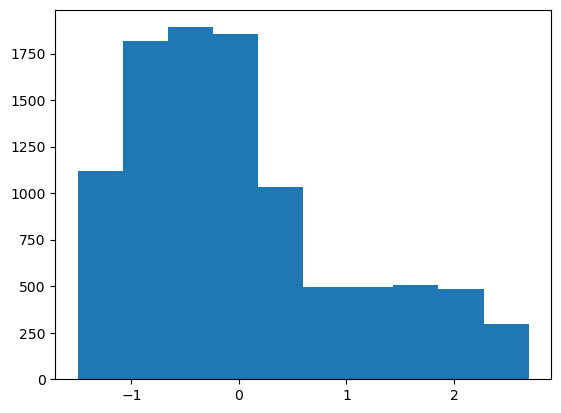

In [31]:
#Additional_charges
#Outlier assessment via histogram
medical_data['Z_Score_Additional_charges']=stats.zscore(medical_data['Additional_charges'])
medical_data[['Additional_charges', 'Z_Score_Additional_charges']].head
plt.hist(medical_data['Z_Score_Additional_charges'])

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Additional_charges, dtype: float64

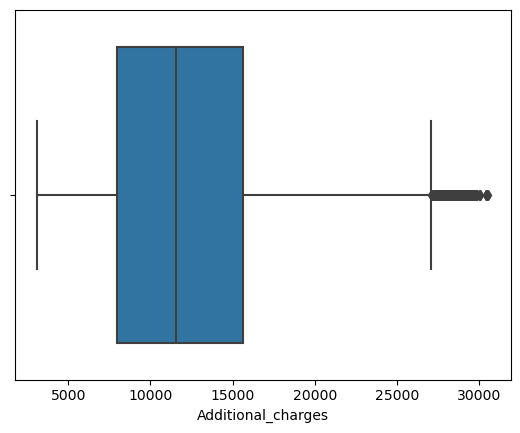

In [32]:
#Additional_charges
#Outlier assessment via box plot
additional_charges_boxplot=seaborn.boxplot(x='Additional_charges', data=medical_data)
additional_charges_outliers = medical_data.query('Z_Score_Additional_charges > 3 | Z_Score_Additional_charges < -3')
additional_charges_outliers['Additional_charges'].describe()

(array([2.130e+02, 1.315e+03, 3.404e+03, 0.000e+00, 3.455e+03, 1.377e+03,
        0.000e+00, 2.250e+02, 1.000e+01, 1.000e+00]),
 array([-2.44090102, -1.76254993, -1.08419885, -0.40584776,  0.27250332,
         0.95085441,  1.62920549,  2.30755658,  2.98590766,  3.66425875,
         4.34260983]),
 <BarContainer object of 10 artists>)

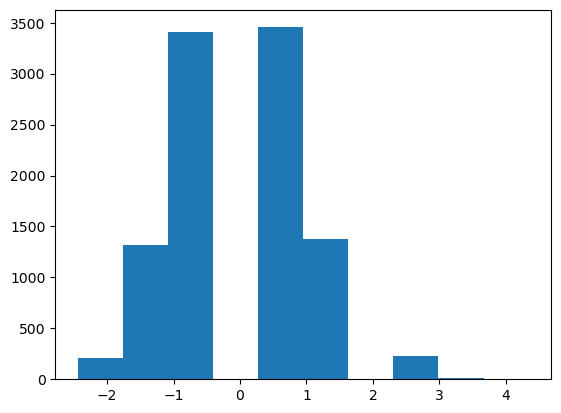

In [33]:
#Item1
#Outlier assessment via histogram
medical_data['Z_Score_Item1']=stats.zscore(medical_data['Item1'])
medical_data[['Item1', 'Z_Score_Item1']].head
plt.hist(medical_data['Z_Score_Item1'])

count    11.000000
mean      7.090909
std       0.301511
min       7.000000
25%       7.000000
50%       7.000000
75%       7.000000
max       8.000000
Name: Item1, dtype: float64

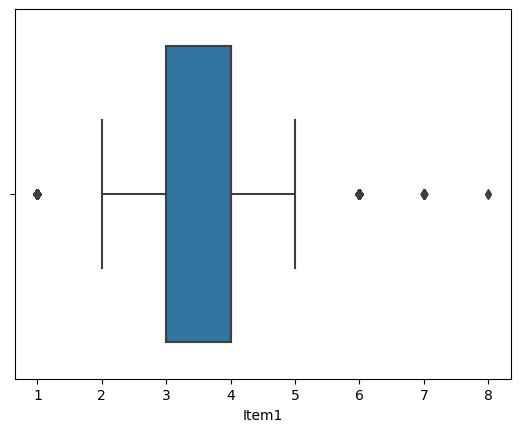

In [34]:
#Item1
#Outlier assessment via box plot
item1_boxplot=seaborn.boxplot(x='Item1', data=medical_data)
item1_outliers = medical_data.query('Z_Score_Item1 > 3 | Z_Score_Item1 < -3')
item1_outliers['Item1'].describe()

(array([ 213., 1360.,    0., 3439.,    0., 3351., 1421.,    0.,  204.,
          12.]),
 array([-2.42246373, -1.8426264 , -1.26278907, -0.68295174, -0.10311441,
         0.47672293,  1.05656026,  1.63639759,  2.21623492,  2.79607225,
         3.37590958]),
 <BarContainer object of 10 artists>)

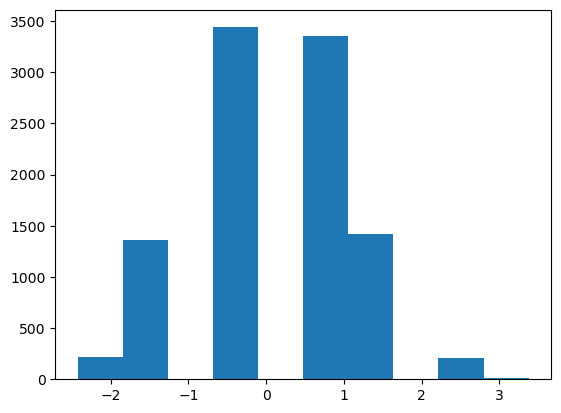

In [35]:
#Item2
#Outlier assessment via histogram
medical_data['Z_Score_Item2']=stats.zscore(medical_data['Item2'])
medical_data[['Item2', 'Z_Score_Item2']].head
plt.hist(medical_data['Z_Score_Item2'])

count    12.0
mean      7.0
std       0.0
min       7.0
25%       7.0
50%       7.0
75%       7.0
max       7.0
Name: Item2, dtype: float64

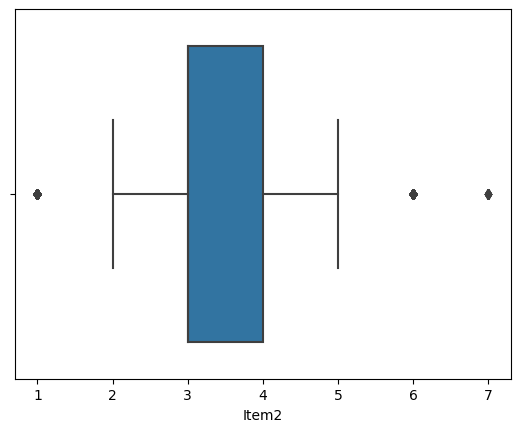

In [36]:
#Item2
#Outlier assessment via box plot
item2_boxplot=seaborn.boxplot(x='Item2', data=medical_data)
item2_outliers = medical_data.query('Z_Score_Item2 > 3 | Z_Score_Item2 < -3')
item2_outliers['Item2'].describe()

(array([2.110e+02, 1.356e+03, 3.379e+03, 0.000e+00, 3.464e+03, 1.358e+03,
        0.000e+00, 2.200e+02, 1.100e+01, 1.000e+00]),
 array([-2.43157855, -1.75374613, -1.07591371, -0.3980813 ,  0.27975112,
         0.95758354,  1.63541596,  2.31324838,  2.9910808 ,  3.66891322,
         4.34674563]),
 <BarContainer object of 10 artists>)

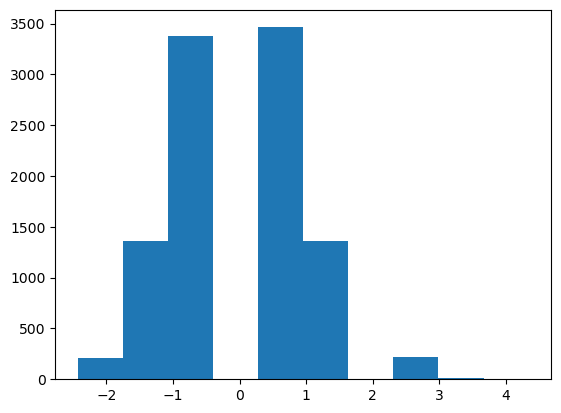

In [37]:
#Item3
#Outlier assessment via histogram
medical_data['Z_Score_Item3']=stats.zscore(medical_data['Item3'])
medical_data[['Item3', 'Z_Score_Item3']].head
plt.hist(medical_data['Z_Score_Item3'])

count    12.000000
mean      7.083333
std       0.288675
min       7.000000
25%       7.000000
50%       7.000000
75%       7.000000
max       8.000000
Name: Item3, dtype: float64

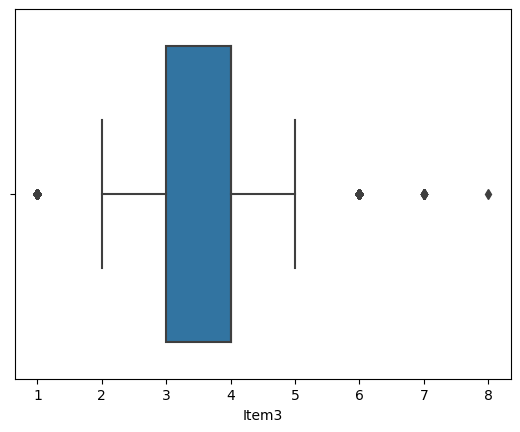

In [38]:
#Item3
#Outlier assessment via box plot
item3_boxplot=seaborn.boxplot(x='Item3', data=medical_data)
item3_outliers = medical_data.query('Z_Score_Item3 > 3 | Z_Score_Item3 < -3')
item3_outliers['Item3'].describe()

(array([ 207., 1346.,    0., 3422., 3394.,    0., 1388.,    0.,  231.,
          12.]),
 array([-2.42716456, -1.84814236, -1.26912016, -0.69009796, -0.11107576,
         0.46794644,  1.04696864,  1.62599084,  2.20501304,  2.78403524,
         3.36305744]),
 <BarContainer object of 10 artists>)

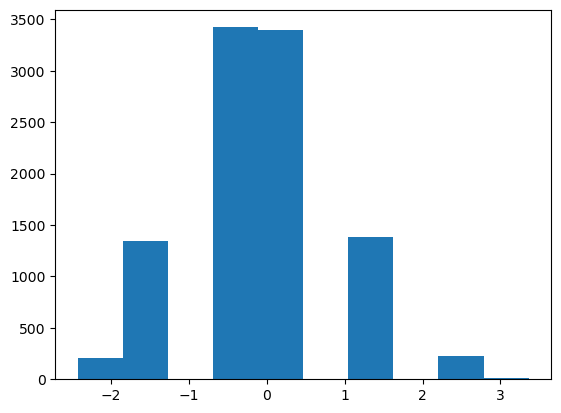

In [39]:
#Item4
#Outlier assessment via histogram
medical_data['Z_Score_Item4']=stats.zscore(medical_data['Item4'])
medical_data[['Item4', 'Z_Score_Item4']].head
plt.hist(medical_data['Z_Score_Item4'])

count    12.0
mean      7.0
std       0.0
min       7.0
25%       7.0
50%       7.0
75%       7.0
max       7.0
Name: Item4, dtype: float64

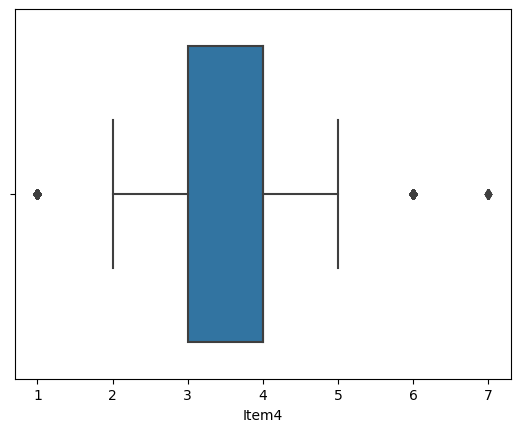

In [40]:
#Item4
#Outlier assessment via box plot
item4_boxplot=seaborn.boxplot(x='Item4', data=medical_data)
item4_outliers = medical_data.query('Z_Score_Item4 > 3 | Z_Score_Item4 < -3')
item4_outliers['Item4'].describe()

(array([ 211., 1380.,    0., 3423., 3446.,    0., 1308.,    0.,  219.,
          13.]),
 array([-2.42384305, -1.84139849, -1.25895392, -0.67650936, -0.0940648 ,
         0.48837977,  1.07082433,  1.65326889,  2.23571346,  2.81815802,
         3.40060259]),
 <BarContainer object of 10 artists>)

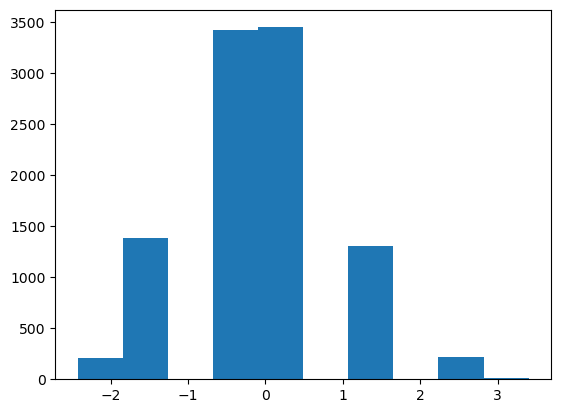

In [41]:
#Item5
#Outlier assessment via histogram
medical_data['Z_Score_Item5']=stats.zscore(medical_data['Item5'])
medical_data[['Item5', 'Z_Score_Item5']].head
plt.hist(medical_data['Z_Score_Item5'])

count    13.0
mean      7.0
std       0.0
min       7.0
25%       7.0
50%       7.0
75%       7.0
max       7.0
Name: Item5, dtype: float64

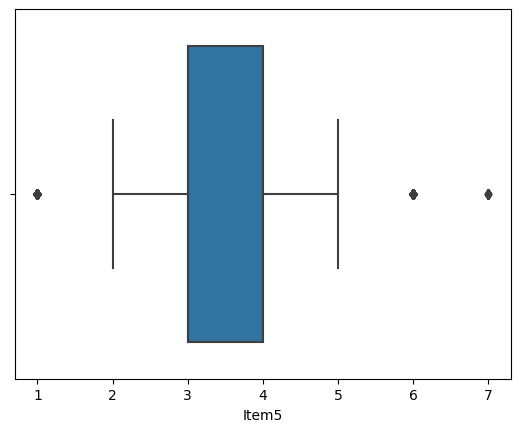

In [42]:
#Item5
#Outlier assessment via box plot
item5_boxplot=seaborn.boxplot(x='Item5', data=medical_data)
item5_outliers = medical_data.query('Z_Score_Item5 > 3 | Z_Score_Item5 < -3')
item5_outliers['Item5'].describe()

(array([ 213., 1319.,    0., 3371., 3464.,    0., 1403.,    0.,  220.,
          10.]),
 array([-2.44351475, -1.86230213, -1.2810895 , -0.69987687, -0.11866424,
         0.46254838,  1.04376101,  1.62497364,  2.20618626,  2.78739889,
         3.36861152]),
 <BarContainer object of 10 artists>)

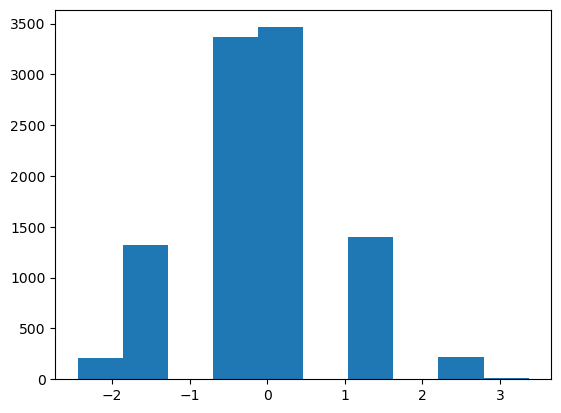

In [43]:
#Item6
#Outlier assessment via histogram
medical_data['Z_Score_Item6']=stats.zscore(medical_data['Item6'])
medical_data[['Item6', 'Z_Score_Item6']].head
plt.hist(medical_data['Z_Score_Item6'])

count    10.0
mean      7.0
std       0.0
min       7.0
25%       7.0
50%       7.0
75%       7.0
max       7.0
Name: Item6, dtype: float64

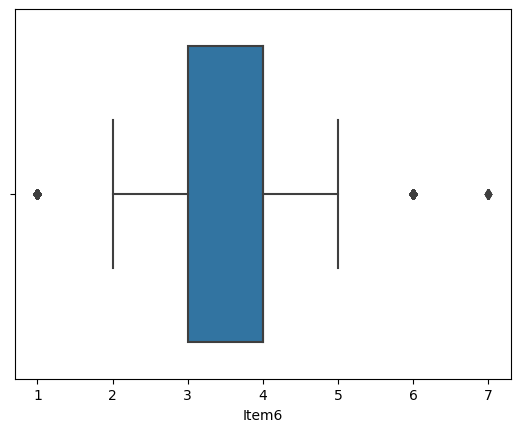

In [44]:
#Item6
#Outlier assessment via box plot
item6_boxplot=seaborn.boxplot(x='Item6', data=medical_data)
item6_outliers = medical_data.query('Z_Score_Item6 > 3 | Z_Score_Item6 < -3')
item6_outliers['Item6'].describe()

(array([ 215., 1345.,    0., 3456.,    0., 3487., 1274.,    0.,  212.,
          11.]),
 array([-2.44185659, -1.85440111, -1.26694564, -0.67949016, -0.09203469,
         0.49542078,  1.08287626,  1.67033173,  2.2577872 ,  2.84524268,
         3.43269815]),
 <BarContainer object of 10 artists>)

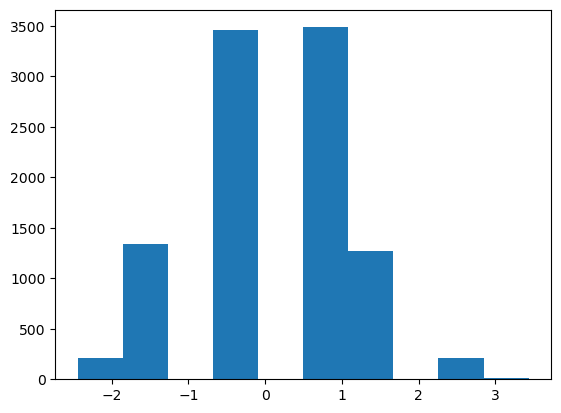

In [45]:
#Item7
#Outlier assessment via histogram
medical_data['Z_Score_Item7']=stats.zscore(medical_data['Item7'])
medical_data[['Item7', 'Z_Score_Item7']].head
plt.hist(medical_data['Z_Score_Item7'])

count    11.0
mean      7.0
std       0.0
min       7.0
25%       7.0
50%       7.0
75%       7.0
max       7.0
Name: Item7, dtype: float64

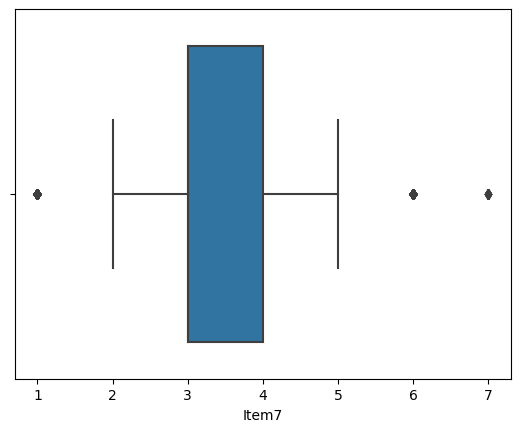

In [46]:
#Item7
#Outlier assessment via box plot
item7_boxplot=seaborn.boxplot(x='Item7', data=medical_data)
item7_outliers = medical_data.query('Z_Score_Item7 > 3 | Z_Score_Item7 < -3')
item7_outliers['Item7'].describe()

(array([ 209., 1391.,    0., 3401.,    0., 3337., 1429.,    0.,  221.,
          12.]),
 array([-2.40794043, -1.83226834, -1.25659624, -0.68092414, -0.10525205,
         0.47042005,  1.04609214,  1.62176424,  2.19743634,  2.77310843,
         3.34878053]),
 <BarContainer object of 10 artists>)

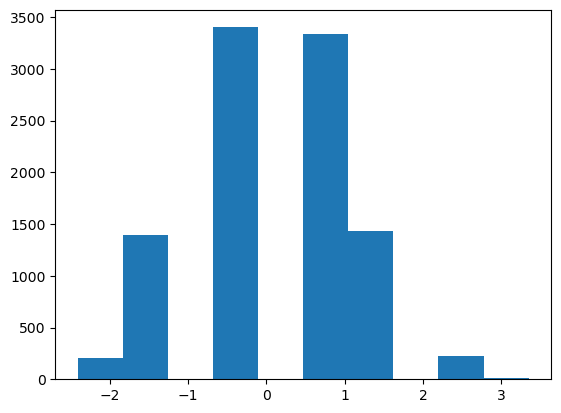

In [47]:
#Item8
#Outlier assessment via histogram
medical_data['Z_Score_Item8']=stats.zscore(medical_data['Item8'])
medical_data[['Item8', 'Z_Score_Item8']].head
plt.hist(medical_data['Z_Score_Item8'])

count    12.0
mean      7.0
std       0.0
min       7.0
25%       7.0
50%       7.0
75%       7.0
max       7.0
Name: Item8, dtype: float64

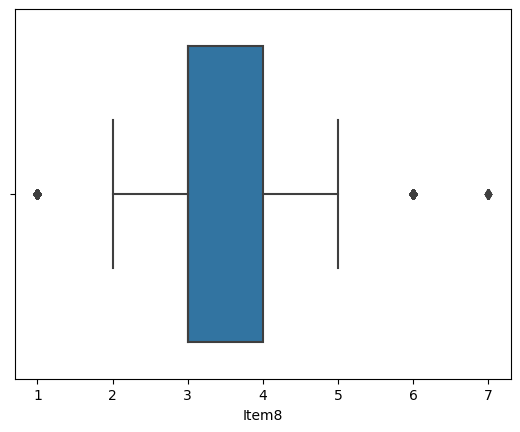

In [48]:
#Item8
#Outlier assessment via box plot
item8_boxplot=seaborn.boxplot(x='Item8', data=medical_data)
item8_outliers = medical_data.query('Z_Score_Item8 > 3 | Z_Score_Item8 < -3')
item8_outliers['Item8'].describe()

##### Categorical variable identification for re-expression via ordinal encoding

In [49]:
#Zip
medical_data['Zip'].unique() #Does not require re-expression

array([35621, 32446, 57110, ..., 8340, 57775, 15108], dtype=object)

In [50]:
#Lat
medical_data['Lat'].unique() #Does not require re-expression

array([34.3496 , 30.84513, 43.54321, ..., 39.43609, 44.10354, 40.49998])

In [51]:
#Lng
medical_data['Lng'].unique() #Does not require re-expression

array([ -86.72508,  -85.22907,  -96.63772, ...,  -74.87302, -102.01593,
        -80.19959])

In [52]:
#Area
medical_data['Area'].unique() #Will be re-expressed

array(['Suburban', 'Urban', 'Rural'], dtype=object)

In [53]:
#Timezone
medical_data['Timezone'].unique() #Does not require re-expression

array(['America/Chicago', 'America/New_York', 'America/Los_Angeles',
       'America/Indiana/Indianapolis', 'America/Detroit',
       'America/Denver', 'America/Nome', 'America/Anchorage',
       'America/Phoenix', 'America/Boise', 'America/Puerto_Rico',
       'America/Yakutat', 'Pacific/Honolulu', 'America/Menominee',
       'America/Kentucky/Louisville', 'America/Indiana/Vincennes',
       'America/Toronto', 'America/Indiana/Marengo',
       'America/Indiana/Winamac', 'America/Indiana/Tell_City',
       'America/Sitka', 'America/Indiana/Knox',
       'America/North_Dakota/New_Salem', 'America/Indiana/Vevay',
       'America/Adak', 'America/North_Dakota/Beulah'], dtype=object)

In [54]:
#Job
medical_data['Job'].unique() #Does not require re-expression

array(['Psychologist, sport and exercise', 'Community development worker',
       'Chief Executive Officer', 'Early years teacher',
       'Health promotion specialist', 'Corporate treasurer',
       'Hydrologist', 'Psychiatric nurse', 'Computer games developer',
       'Production assistant, radio', 'Contractor',
       'Surveyor, planning and development',
       'English as a second language teacher', 'Actuary', 'Media planner',
       'Fast food restaurant manager', 'Horticulturist, commercial',
       'Secretary, company', 'Designer, graphic', 'Personnel officer',
       'Telecommunications researcher', 'Restaurant manager, fast food',
       'Surveyor, minerals', 'Architectural technologist',
       'Therapist, speech and language', 'Accounting technician',
       'Glass blower/designer', 'Travel agency manager', 'Illustrator',
       'Police officer', 'Accountant, chartered public finance',
       'Sport and exercise psychologist', 'Pensions consultant',
       'Community educat

In [55]:
#Marital
medical_data['Marital'].unique() #Will be re-expressed

array(['Divorced', 'Married', 'Widowed', 'Never Married', 'Separated'],
      dtype=object)

In [56]:
#Gender
medical_data['Gender'].unique() #Will be re-expressed

array(['Male', 'Female', 'Prefer not to answer'], dtype=object)

In [57]:
#Soft_drink
medical_data['Soft_drink'].unique() #Will be re-expressed

array([nan, 'No', 'Yes'], dtype=object)

In [58]:
#HighBlood
medical_data['HighBlood'].unique() #Will be re-expressed

array(['Yes', 'No'], dtype=object)

In [59]:
#Stroke
medical_data['Stroke'].unique() #Will be re-expressed

array(['No', 'Yes'], dtype=object)

In [60]:
#Overweight
medical_data['Overweight'].unique() #Does not require re-expression

array([0.0, 1.0, nan], dtype=object)

In [61]:
#Arthritis
medical_data['Arthritis'].unique() #Will be re-expressed

array(['Yes', 'No'], dtype=object)

In [62]:
#Diabetes
medical_data['Diabetes'].unique() #Will be re-expressed

array(['Yes', 'No'], dtype=object)

In [63]:
#Hyperlipidemia
medical_data['Hyperlipidemia'].unique() #Will be re-expressed

array(['No', 'Yes'], dtype=object)

In [64]:
#BackPain
medical_data['BackPain'].unique() #Will be re-expressed

array(['Yes', 'No'], dtype=object)

In [65]:
#Anxiety
medical_data['Anxiety'].unique() #Does not require re-expression

array([1.0, nan, 0.0], dtype=object)

In [66]:
#Allergic_rhinitis
medical_data['Allergic_rhinitis'].unique() #Will be re-expressed

array(['Yes', 'No'], dtype=object)

In [67]:
#Reflux_esophagitis
medical_data['Reflux_esophagitis'].unique() #Will be re-expressed

array(['No', 'Yes'], dtype=object)

In [68]:
#Asthma
medical_data['Asthma'].unique() #Will be re-expressed

array(['Yes', 'No'], dtype=object)

In [69]:
#Services
medical_data['Services'].unique() #Will be re-expressed

array(['Blood Work', 'Intravenous', 'CT Scan', 'MRI'], dtype=object)

## Part III: Data Cleaning

### D.  Summarize the data-cleaning process by doing the following:

#### 1.  Describe the findings for the data quality issues found from the implementation of the data-cleaning plan from part C.

Duplicates: 

After checking for duplicates using the duplicated() and value_counts() function, it was noted that all 10000 rows had no duplicates. Therefore, no treatment was needed for any duplicate values.

Missing values: 

There were 7 variables that had missing values. 2588 values were missing from “Children,” 2414 values were missing from “Age,” 2464 values were missing from “Income,” 2467 values were missing from “Soft_drink,” 982 values were missing from “Overweight,” 984 values were missing from “Anxiety,” and 1056 values were missing from “Initial_days.”

Outliers:

“Population” has 218 outliers, with a minimum value of 54,443, a maximum value of 122,814, and a mean of 67,419.33.
“Children” has 303 outliers, with a minimum value of 8, a maximum value of 10, and a mean of 8.69.
“Age” does not have any outliers.
“Income” has 180 outliers, with a minimum value of 114,215.99, a maximum value of 207,249.13, and a mean of 138,626.75
“VitD_levels” has 500 outliers, with a minimum of 40.84, a maximum of 53.02, and a mean of 47.03.
“Doc_visits” has 8 outliers, with a minimum of 1, a maximum of 9, and a mean of 3.
“Full_meals_eaten” has 33 outliers, with a minimum of 5, a maximum of 7, and a mean of 5.3.
“VitD_supp” has 70 outliers, with a minimum of 3, a maximum of 5, and a mean of 3.1.
“Initial_days” does not have any outliers.
“TotalCharge” has 276 outliers, with a minimum of 16,053.46, a maximum of 21,524.22, and a mean of 18,862.99.
“Additional_charges” does not have any outliers.
“Item1” has 11 outliers, with a minimum of 7, a maximum of 8, and a mean of 7.09.
“Item2” has 12 outliers, with a minimum of 7, a maximum of 7, and a mean of 7.
“Item3” has 12 outliers, with a minimum of 7, a maximum of 8, and a mean of 7.08.
“Item4” has 12 outliers, with a minimum of 7, a maximum of 7, and a mean of 7.
“Item5” has 13 outliers, with a minimum of 7, a maximum of 7, and a mean of 7.
“Item6” has 10 outliers, with a minimum of 7, a maximum of 7, and a mean of 7.
“Item7” has 11 outliers, with a minimum of 7, a maximum of 7, and a mean of 7.
“Item8” has 12 outliers, with a minimum of 7, a maximum of 7, and a mean of 7.

Incorrect data types:

“Zip” had datatype int64. “Overweight” had type float64. “Anxiety” had type float64. These datatypes could create quality and consistency issues that could impact data analysis. For example, there are zip codes with leading zeroes. If expressed as an integer, these leading zeroes could be removed, which would render the zip codes invalid.

Categorical variable re-expression:

Each categorical variable was assessed to see whether the variable could be ordinally encoded. This was done using the unique() function to identify which variables had values that would work with ordinal encoding.

The following variables were not eligible for ordinal expression and were not treated: “Lat,” “Lng,” “Timezone,” “Job,” “Overweight,” and “Anxiety.”

The following variables were able to be ordinally expressed and were treated (explained in Section D2 and D3): “Area,” “Marital,” “Gender,” “Soft_drink,” “HighBlood,” “Stroke,” “Arthritis,” “Diabetes,” “Hyperlipidemia,” “BackPain,” “Allergic_rhinitis,” “Reflux_esophagitis,” “Asthma,” and “Services.”  


#### 2.  Justify your methods for mitigating the data quality issues in the data set.

Duplicates: 

There were no duplicates in the dataset, therefore no treatment was needed for any duplicates.

Missing values: 

Missing values were treated using a combination of the hist() function and the fillna() function. The hist() function was used to identify the skew of the data, and the fillna() function was used to impute the data based on the skew and data type.

In Webinar 2 (Middleton, 2022a), it is noted that for quantitative variables, mean imputation is acceptable for normally distributed data, while median imputation is suggested for skewed data. Children, Income, and Initial_days are all skewed left, and were imputed using median imputation. Age had a normal distribution, and was imputed using mean imputation.

For categorical variables, Webinar 2 (Middleton, 2022a) states “For categorical data use the mode.” Soft_drink, Overweight, and Anxiety were all imputed using mode imputation.

Outliers: 

Regarding outliers, Webinar 2 (Middleton, 2022a) notes that “If you find out that it is not an error or a legitimate entry, then you can retain the outlier, but note that it exists.” In Question D1, all outliers have their count, minimum, maximum, and mean values noted. Based on these values, it does not appear that any outliers are in error (for example, a value of 20 in Item1) and all appear to be legitimate entries. For this reason, no treatment was needed and all outliers were retained.

Incorrect data types:

Zip, Overweight, and Anxiety were all converted to objects using the astype() method. According to Moffitt (n.d.), “When doing data analysis, it is important to make sure you are using the correct data types; otherwise you may get unexpected results or errors.”

Zip, Overweight, and Anxiety are all categorical variables with numeric data types. This could create consistency issues. In addition, Zip could have an issue where leading zeroes are removed due to the int datatype. 

Practical Business Python notes that “The simplest way to convert a pandas column of data to a different type is to use astype().” This function was used, and the dtypes function was used to assess whether the conversions were successful.

Categorical variable re-expression:

Categorical variables were re-expressed using the data dictionary method explained in the textbook. On Page 37 of the textbook (Larose & Larose, 2019), it is stated that “We need to set up a dictionary specifically for converting the categorical variables in the education_numeric variable to numeric values.” Based on this, the following variables were re-expressed via ordinal expression: Area, Marital, Gender, Soft_drink, HighBlood, Stroke, Arthritis, Diabetes, Hyperlipidemia, BackPain, Allergic_rhinitis, Reflux_esophagitis, Asthma, and Services. The re-expressed variables have been added to the dataset under the “Variable_numeric” format (Area_numeric, Marital_numeric, etc.)

#### 3.  Summarize the outcome from the implementation of each data-cleaning step.

Duplicate detection was performed, and no duplicates were identified, therefore no treatment was needed. 

Missing values were assessed and imputed using a variety of statistical measures, depending on whether the data was quantitative or categorical. In Section D4, the missingness matrix and isna() function demonstrate that after treatment, there are no more missing values.

Outliers were assessed and the values were deemed to be in line with normal values, therefore no treatment was needed.

Incorrect data types were converted to the correct type for analysis. The results of these conversions can be seen in response to Section D4, using the dtypes() function.

Categorical variables were re-expressed using data dictionaries. The results of these re-expressions can be seen in response to Section D4, using the unique() function on the new “variable_numeric” variables.

#### 4.  Provide the annotated code you will use to mitigate the data quality issues—including anomalies—in the data set in an executable script file.

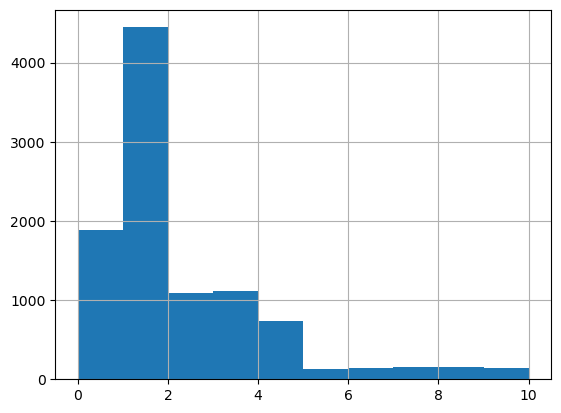

In [70]:
#Impute missing values for Children (quantitative data method)
medical_data['Children'].hist() #Skewed left, median imputation
medical_data['Children'].fillna(medical_data['Children'].median(), inplace = True)

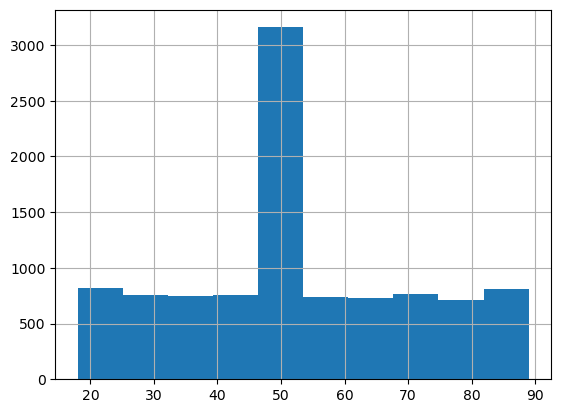

In [71]:
#Impute missing values for Age (quantitative data method)
medical_data['Age'].hist() #Normal, use mean
medical_data['Age'].fillna(medical_data['Age'].mean(), inplace = True)

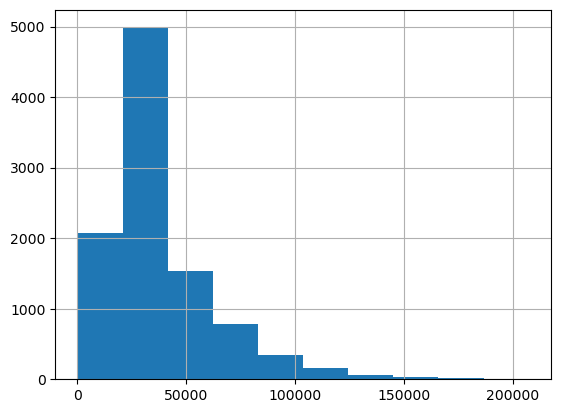

In [72]:
#Impute missing values for Income (quantitative data method)
medical_data['Income'].hist() #Skewed left, use median
medical_data['Income'].fillna(medical_data['Income'].median(), inplace = True)

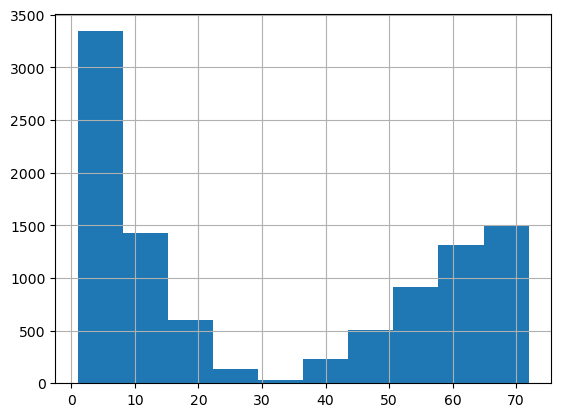

In [73]:
#Impute missing values for Initial_days (quantitative data method)
medical_data['Initial_days'].hist() #Skewed left and right, use median
medical_data['Initial_days'].fillna(medical_data['Children'].median(), inplace = True)

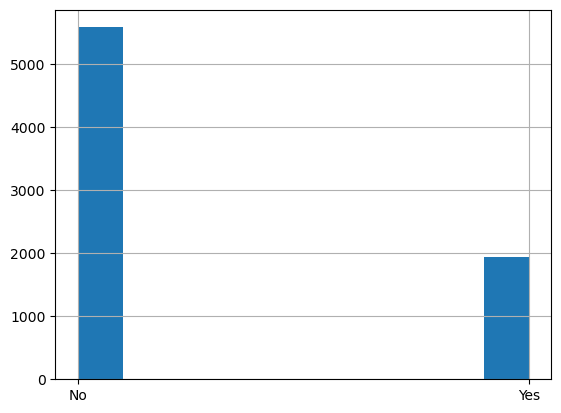

In [74]:
#Impute for Soft_drink (categorical data method)
medical_data['Soft_drink'].hist()
medical_data['Soft_drink'] = medical_data['Soft_drink'].fillna(medical_data['Soft_drink'].mode()[0])

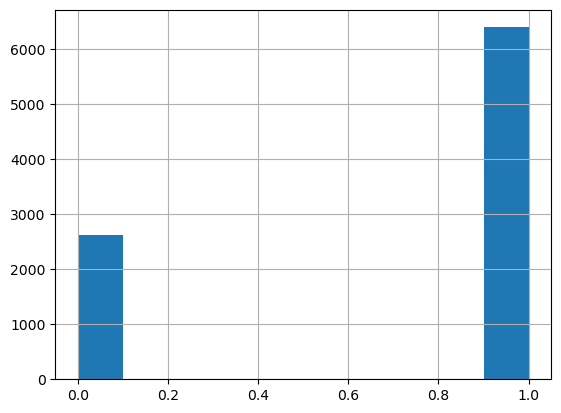

In [75]:
#Impute for Overweight (categorical data method)
medical_data['Overweight'].hist()
medical_data['Overweight'] = medical_data['Overweight'].fillna(medical_data['Overweight'].mode()[0])

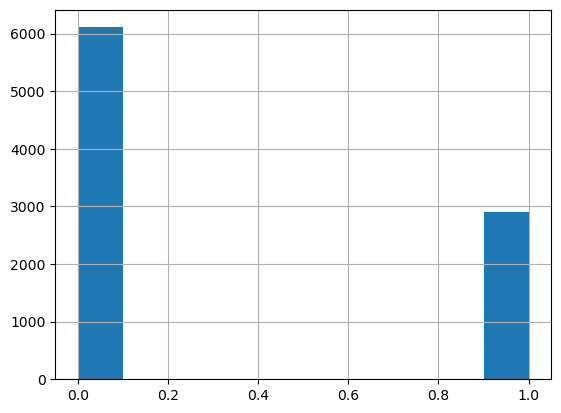

In [76]:
#Impute for Anxiety (categorical data method)
medical_data['Anxiety'].hist()
medical_data['Anxiety'] = medical_data['Anxiety'].fillna(medical_data['Anxiety'].mode()[0])

In [77]:
#Check if all nulls are removed from our columns with missing data. 
pd.options.display.max_rows = 4000
medical_data.isnull().sum()

Unnamed: 0                    0
CaseOrder                     0
Customer_id                   0
Interaction                   0
UID                           0
City                          0
State                         0
County                        0
Zip                           0
Lat                           0
Lng                           0
Population                    0
Area                          0
Timezone                      0
Job                           0
Children                      0
Age                           0
Education                     0
Employment                    0
Income                        0
Marital                       0
Gender                        0
ReAdmis                       0
VitD_levels                   0
Doc_visits                    0
Full_meals_eaten              0
VitD_supp                     0
Soft_drink                    0
Initial_admin                 0
HighBlood                     0
Stroke                        0
Complica

<AxesSubplot:>

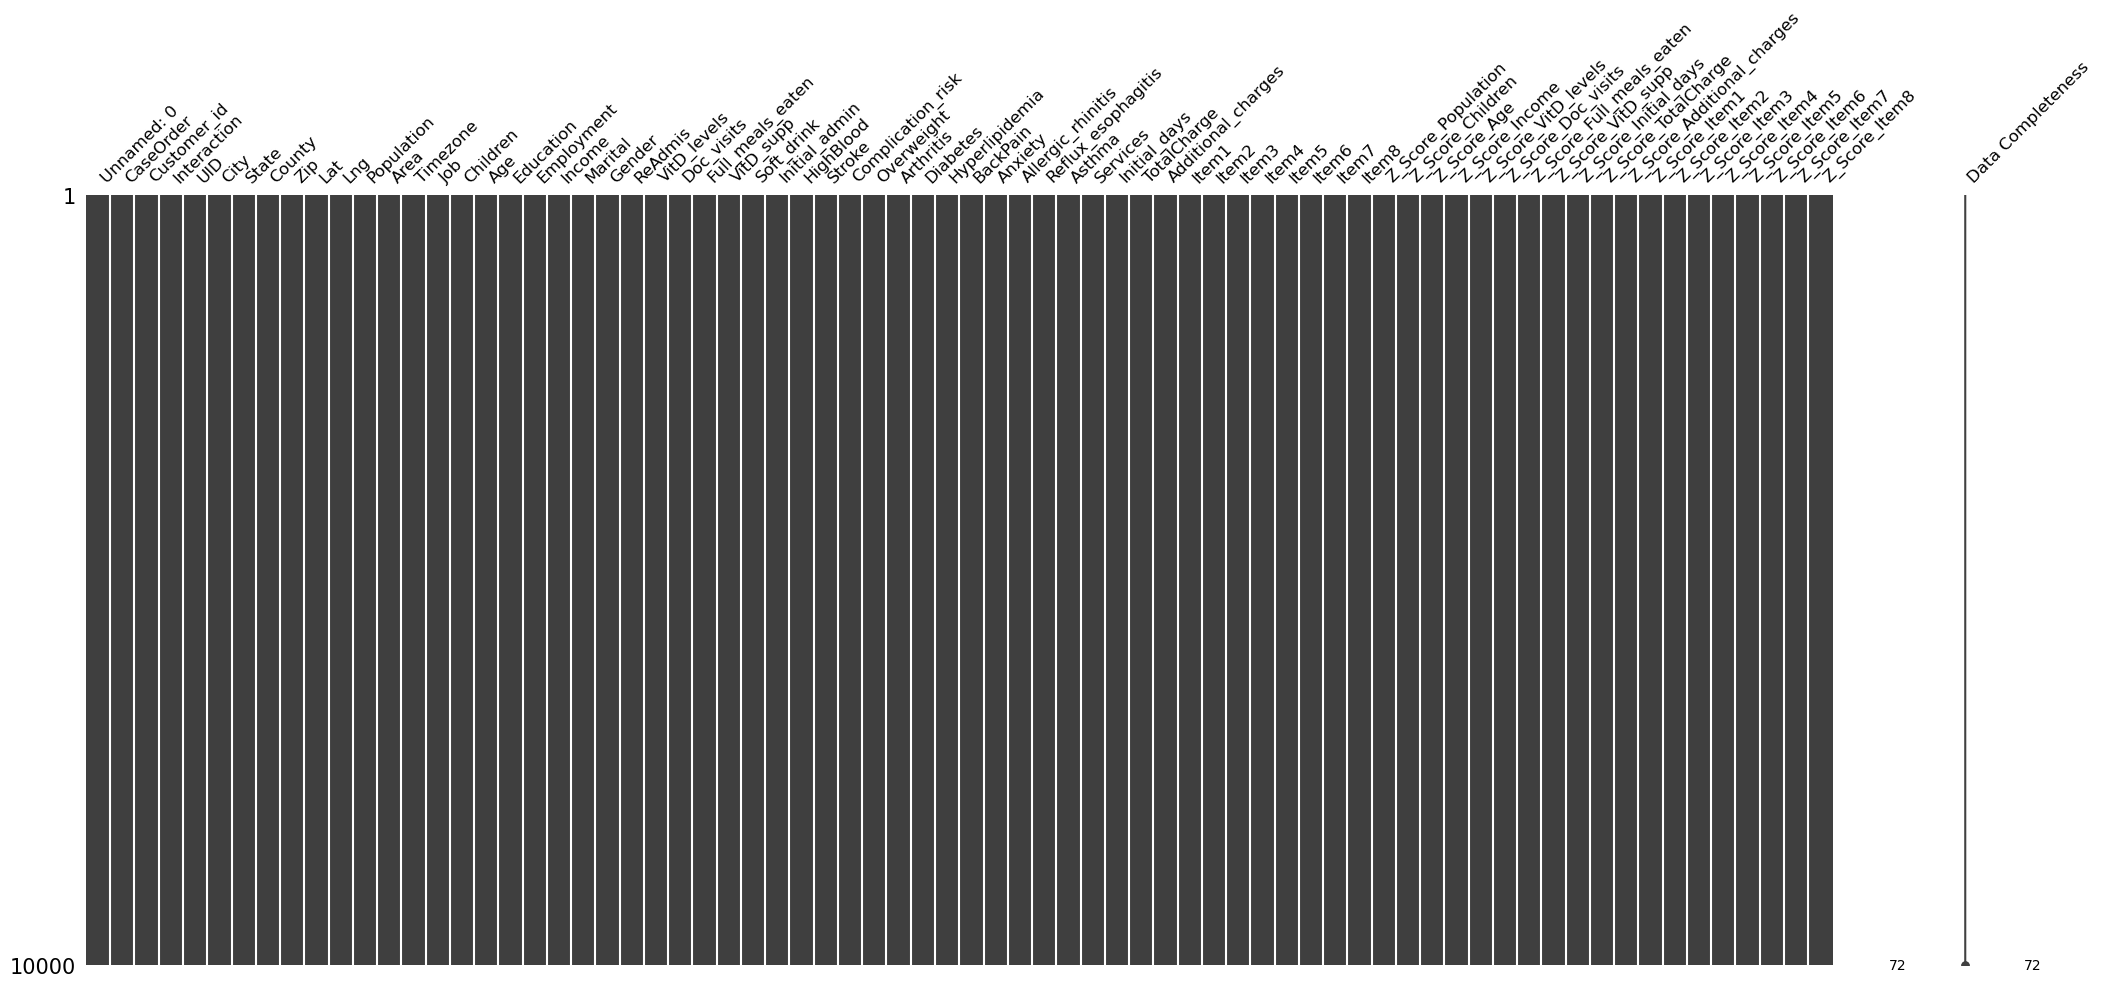

In [78]:
#Visualize missingness
msno.matrix(medical_data, fontsize = 12, labels = True)

In [79]:
#Re-visit Section C4 to demonstrate that Zip, Overweight, and Anxiety were corrected.

In [80]:
#Categorical/Qualitative variable re-expression

#Area
medical_data['Area_numeric'] = medical_data['Area']
dict_area = {"Area_numeric": {"Rural": 0, "Suburban": 1, "Urban": 2}}
medical_data.replace(dict_area, inplace = True)
medical_data['Area_numeric'].unique()

array([1, 2, 0], dtype=int64)

In [81]:
#Categorical/Qualitative variable re-expression

#Marital
medical_data['Marital_numeric'] = medical_data['Marital']
dict_marital = {"Marital_numeric": {"Never Married": 0, "Married": 1, "Separated": 2, "Divorced": 3, "Widowed": 4}}
medical_data.replace(dict_marital, inplace = True)
medical_data['Marital_numeric'].unique()

array([3, 1, 4, 0, 2], dtype=int64)

In [82]:
#Categorical/Qualitative variable re-expression

#Gender
medical_data['Gender_numeric'] = medical_data['Gender']
dict_gender = {"Gender_numeric": {"Prefer not to answer": 0, "Male": 1, "Female": 2}}
medical_data.replace(dict_gender, inplace = True)
medical_data['Gender_numeric'].unique()

array([1, 2, 0], dtype=int64)

In [83]:
#Categorical/Qualitative variable re-expression

#Soft_drink
medical_data['Soft_drink_numeric'] = medical_data['Soft_drink']
dict_soft_drink = {"Soft_drink_numeric": {"nan": 0, "No": 1, "Yes": 2}}
medical_data.replace(dict_soft_drink, inplace = True)
medical_data['Soft_drink_numeric'].unique()

array([1, 2], dtype=int64)

In [84]:
#Categorical/Qualitative variable re-expression

#HighBlood
medical_data['HighBlood_numeric'] = medical_data['HighBlood']
dict_HighBlood = {"HighBlood_numeric": {"No": 0, "Yes": 1}}
medical_data.replace(dict_HighBlood, inplace = True)
medical_data['HighBlood_numeric'].unique()

array([1, 0], dtype=int64)

In [85]:
#Categorical/Qualitative variable re-expression

#Stroke
medical_data['Stroke_numeric'] = medical_data['Stroke']
dict_Stroke = {"Stroke_numeric": {"No": 0, "Yes": 1}}
medical_data.replace(dict_Stroke, inplace = True)
medical_data['Stroke_numeric'].unique()

array([0, 1], dtype=int64)

In [86]:
#Categorical/Qualitative variable re-expression

#Arthritis
medical_data['Arthritis_numeric'] = medical_data['Arthritis']
dict_Arthritis = {"Arthritis_numeric": {"No": 0, "Yes": 1}}
medical_data.replace(dict_Arthritis, inplace = True)
medical_data['Arthritis_numeric'].unique()

array([1, 0], dtype=int64)

In [87]:
#Categorical/Qualitative variable re-expression

#Diabetes
medical_data['Diabetes_numeric'] = medical_data['Diabetes']
dict_Diabetes = {"Diabetes_numeric": {"No": 0, "Yes": 1}}
medical_data.replace(dict_Diabetes, inplace = True)
medical_data['Diabetes_numeric'].unique()

array([1, 0], dtype=int64)

In [88]:
#Categorical/Qualitative variable re-expression

#Hyperlipidemia
medical_data['Hyperlipidemia_numeric'] = medical_data['Hyperlipidemia']
dict_Hyperlipidemia = {"Hyperlipidemia_numeric": {"No": 0, "Yes": 1}}
medical_data.replace(dict_Hyperlipidemia, inplace = True)
medical_data['Hyperlipidemia_numeric'].unique()

array([0, 1], dtype=int64)

In [89]:
#Categorical/Qualitative variable re-expression

#BackPain
medical_data['BackPain_numeric'] = medical_data['BackPain']
dict_BackPain = {"BackPain_numeric": {"No": 0, "Yes": 1}}
medical_data.replace(dict_BackPain, inplace = True)
medical_data['BackPain_numeric'].unique()

array([1, 0], dtype=int64)

In [90]:
#Categorical/Qualitative variable re-expression

#Allergic_rhinitis
medical_data['Allergic_rhinitis_numeric'] = medical_data['Allergic_rhinitis']
dict_Allergic_rhinitis = {"Allergic_rhinitis_numeric": {"No": 0, "Yes": 1}}
medical_data.replace(dict_Allergic_rhinitis, inplace = True)
medical_data['Allergic_rhinitis_numeric'].unique()

array([1, 0], dtype=int64)

In [91]:
#Categorical/Qualitative variable re-expression

#Reflux_esophagitis
medical_data['Reflux_esophagitis_numeric'] = medical_data['Reflux_esophagitis']
dict_Reflux_esophagitis = {"Reflux_esophagitis_numeric": {"No": 0, "Yes": 1}}
medical_data.replace(dict_Reflux_esophagitis, inplace = True)
medical_data['Reflux_esophagitis_numeric'].unique()

array([0, 1], dtype=int64)

In [92]:
#Categorical/Qualitative variable re-expression

#Asthma
medical_data['Asthma_numeric'] = medical_data['Asthma']
dict_Asthma = {"Asthma_numeric": {"No": 0, "Yes": 1}}
medical_data.replace(dict_Asthma, inplace = True)
medical_data['Asthma_numeric'].unique()

array([1, 0], dtype=int64)

In [93]:
#Categorical/Qualitative variable re-expression

#Services
medical_data['Services_numeric'] = medical_data['Services']
dict_Services = {"Services_numeric": {"CT Scan": 0, "MRI": 1, "Blood Work": 2, "Intravenous": 3}}
medical_data.replace(dict_Services, inplace = True)
medical_data['Services_numeric'].unique()

array([2, 3, 0, 1], dtype=int64)

#### 5.  Provide a copy of the cleaned data set as a CSV file.

Please see the attached file named 'cleaned_medical_data.csv' that has been uploaded as part of this assessment.

In [94]:
medical_data.to_csv('cleaned_medical_data.csv')

#### 6.  Summarize the limitations of the data-cleaning process.

Duplicates: 

One disadvantage of using the duplicated() method is that if there was an instance that was genuinely a duplicate, but was perhaps spelled incorrectly or contained some other type of data quality issue, the duplicated() function would not detect the duplicate. Using this function relies on the assumption that this type of data quality issue did not occur.

Missing values: 

The primary disadvantage of the method used to treat missing values is that missing values were only imputed using simple imputation techniques. There are other, more advanced imputation techniques such as forward or backward fill or K-Nearest Neighbor Imputation. While the methods chosen did help ensure completeness of the data, there may still be a method that returns results more representative of the rest of the data. 

Outliers: 

The major disadvantage of choosing not to treat outliers is that those data points can still skew the results. If the analysis required using the average of a variable that contains outliers, making sure to choose the correct average method would be incredibly important. Even if the outliers are genuine and valid responses, they can still impact the results of the data in a way that would reduce how representative those results are to the data itself.

Incorrect data types:

A disadvantage of correcting the data types is that it relies on the assumption that the data types have been properly corrected for the analysis that is intended. If someone were to attempt a different analysis, they may very well want zip codes presented in their original form. In this sense, the big disadvantage is that the data types are correct for the current research question, but not necessarily all research questions.

Categorical variable re-expression:

Similar to the issue with incorrect data types, there is a fair amount of subjectivity in the way that categorical variables were re-expressed. I chose the order of the values using the data dictionary method, but there is no guarantee that this is the true or correct order. If someone was to run an analysis on the cleaned data, their idea of the correct order might differ from the order I chose, which could cause results to be interpreted incorrectly by accidentally misreading the data dictionary.

#### 7.  Discuss how the limitations summarized in part D6 could affect the analysis of the question or decision from part A.

A data analyst that was using the now-cleaned data for analysis may encounter several issues. Primarily, by virtue of not cleaning the data themselves, they would be missing the understanding of why the data was cleaned in the ways that it was. Not understanding the steps used in the process could lead to incorrect assumptions about why the data was cleaned in a particular way.

Additionally, the data analyst would be beholden to the choices and assumptions that were made in areas such as outlier treatment. I decided that all of the outliers were valid and justified, but someone else may have a different opinion about whether outliers should be retained. If a data analyst preferred to drop outliers, this now-cleaned data would present an issue for them due to it retaining the outliers. Also, as mentioned above, categorical variable re-expression is fairly subjective in terms of which values respond to which numbers in the data dictionary, and that subjectivity could perhaps cause a data analyst to reach erroneous conclusions.

The variables needed for the question from part A would be 'Marital' and 'HighBlood.' Both of these variables were re-expressed, and if a data analyst was not familiar with how those variables were re-expressed, it could lead to confusion and potentially erroneous conclusions.

### E.  Apply principal component analysis (PCA) to identify the significant features of the data set by doing the following:

#### 1.  Identify the total number of principal components and provide the output of the principal components loading matrix.

There are 11 principle components that meet the criteria for being a principle component.

In [95]:
medical_data_pca = medical_data[['Population', 'Children', 'Age', 'Income', 
                                 'VitD_levels', 'Doc_visits', 'Full_meals_eaten',
                                 'VitD_supp', 'Initial_days', 'TotalCharge', 
                                 'Additional_charges']]
medical_data_pca_normalized = (medical_data_pca - medical_data_pca.mean())/medical_data_pca.std()
pca = PCA(n_components=medical_data_pca.shape[1])
pca.fit(medical_data_pca_normalized)
medical_data_pca2 = pd.DataFrame(pca.transform(medical_data_pca_normalized), columns = ['PC1', 'PC2', 'PC3', 'PC4', 
                                 'PC5', 'PC6', 'PC7',
                                 'PC8', 'PC9', 'PC10', 
                                 'PC11'])
loadings = pd.DataFrame(pca.components_.T, columns = ['PC1', 'PC2', 'PC3', 'PC4', 
                                 'PC5', 'PC6', 'PC7',
                                 'PC8', 'PC9', 'PC10', 
                                 'PC11'], index = medical_data_pca_normalized.columns)
pd.set_option('display.max_columns', None)
loadings                   

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
Population,0.018064,-0.026714,0.514890,0.024091,-0.033296,0.554834,0.049155,-0.234540,0.605618,-0.010910,-0.001057
Children,0.003370,0.011594,0.138430,-0.053410,0.875867,0.205893,0.246635,0.282255,-0.166500,-0.009104,0.001392
Age,0.094129,0.699643,0.019395,-0.024118,-0.014995,0.004217,-0.007477,-0.025061,-0.013961,-0.706580,0.017452
Income,-0.007978,-0.004915,0.164164,0.573555,0.342158,-0.374156,-0.207071,-0.586409,-0.011196,-0.007277,0.000301
VitD_levels,0.557802,-0.066616,-0.247649,0.313256,-0.076963,0.127343,0.427913,-0.047287,0.003164,-0.023567,-0.562947
Doc_visits,-0.006333,0.013234,0.188537,0.605954,-0.165562,0.322456,-0.395272,0.487832,-0.267240,-0.005667,-0.000717
Full_meals_eaten,-0.005400,0.035914,-0.556802,0.140359,0.241878,-0.055805,-0.322347,0.259254,0.660377,-0.009406,0.005059
VitD_supp,0.033208,0.010413,0.444543,0.134177,-0.101391,-0.600142,0.325398,0.458118,0.311346,-0.004924,-0.000302
Initial_days,0.420633,-0.075297,0.288205,-0.404940,0.111014,-0.161587,-0.586940,0.054947,-0.022585,-0.005992,-0.428791
TotalCharge,0.701723,-0.090298,-0.017262,0.003855,0.002515,0.004799,-0.013411,-0.006341,-0.014397,0.021526,0.705831


#### 2.  Justify the reduced number of the principal components and include a screenshot of a scree plot.

Based on the scree plot, three principle components (PC1, PC2 and PC3) should be kept. Webinar 4 (Middleton, 2022b) notes that, per the Kaiser rule, PCs with eigenvalues greater than 1 are recommended to be retained. From the scree plot, we can see that the first three components have eigenvalues greater than 1, while the fourth component looks to be at one or slightly below one. For this reason, PC1, PC2 and PC3 are the three principle components that should be retained.

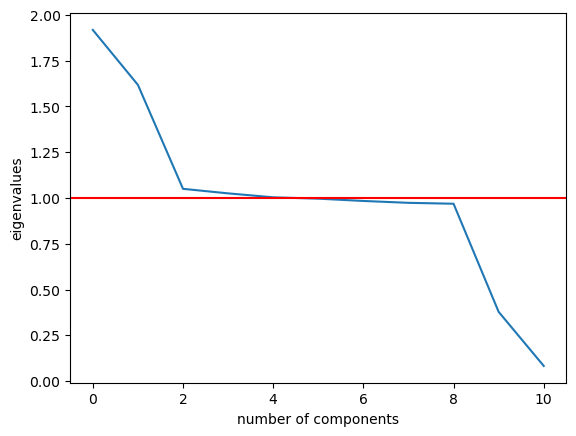

In [96]:
cov_matrix= np.dot(medical_data_pca_normalized.T, medical_data_pca_normalized) / medical_data_pca.shape[0]
eigenvalues = [np.dot(eigenvector.T, np.dot(cov_matrix, eigenvector)) for eigenvector in pca.components_]
plt.plot(eigenvalues)
plt.xlabel('number of components')
plt.ylabel('eigenvalues')
plt.axhline(y=1, color = "red")
plt.show()

#### 3.  Describe how the organization would benefit from the use of PCA.

Principle Component Analysis can have many benefits for an organization. Oftentimes, the data analyst will be given a dataset with seemingly countless variables, and there may not be a clear idea of which variables impact and interact with other variables. In addition, several variables may overlap and say the same thing. 

By utilizing dimensionality reduction, the analyst can focus only on the variables that have the highest impact on other variables. If, for example, the analyst wanted to run a machine learning model on the data, reducing the dimensions of the data to as few as possible would drastically decrease the amount of non-impactful data that the machine learning model would interpret. In turn, this would decrease the time needed to run the model.

PC1, PC2, and PC3 are the principle components that have been retained. From the PCA loadings matrix, “VitD_levels” and “TotalCharge” have the highest coefficients for PC1, at .56 and .70, respectively. “Age” and “Additional_charges” have the highest coefficients for PC2, at 0.7 for both. For PC3, the variables with the strongest coefficients (positive or negative) are "Full_meals_eaten" at -0.56 and "Population" at 0.51. As such, these are the variables that are contributing the most to PC1, PC2 and PC3, respectively.

## References

Larose, C.D., & Larose, D. T. (2019). Data science using Python and R.

Middleton, K. (2022a, October). Webinar 2: Getting Started Webinar Missing Values and Outliers [Webinar]. Western Governors University.
https://wgu.hosted.panopto.com/Panopto/Pages/Viewer.aspx?id=d3af9533-0b7f-4d42-9db2-af48002f4799
    
Middleton, K. (2022b, November). Webinar 4: Getting Started with PCA [Webinar]. Western Governors University.
https://wgu.hosted.panopto.com/Panopto/Pages/Viewer.aspx?id=7b31791b-24e8-4077-ba1a-af5d0005144c

Nkmk. (2021). pandas: Find and remove duplicate rows of DataFrame, Series. note.nkmk.me. https://note.nkmk.me/en/python-pandas-duplicated-drop-duplicates/

R or Python. (2022, November 16). Western Governors University. https://www.wgu.edu/online-it-degrees/programming-languages/r-or-python.html#_

Moffitt, C. (n.d.). Overview of Pandas Data Types. Practical Business Python. https://pbpython.com/pandas_dtypes.html